<a href="https://colab.research.google.com/github/caviteri/Ciencia-de-Datos-2026/blob/main/Ciencia_de_Datos_Semana_07_Filtro_de_Wiener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller Práctico: Generación de Datos Sintéticos con Modelos ARMA**

Maestría en Ingeniería Electrónica

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera

En este cuaderno se estudia el diseño de un predictor lineal óptimo conocido como Filtro de Wiener. El objetivo es minimizar el error cuadrático medio (MMSE) de las predicciones (estimaciones) del valor futuro de una serie de tiempo con base en sus valores pasados. El filtro se diseña al resolver las ecuaciones normales de Wiener-Hopf ($R_x​a=r_x$​) utilizando la matriz de autocorrelación $R_x$ y el vector de correlación cruzada $r_x$. Se aplicará este ejemplo a los rendimientos del S&P 500.

In [52]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg as la
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## **1. Obtención y Normalización de Datos**
Se descargan los últimos 10 años del índice S&P 500. Se calculan los rendimientos diarios porcentuales y se resta la media empírica para garantizar un proceso de media cero.

In [53]:
# 1. Descargar 10 años de datos del S&P 500
data = yf.download('^GSPC', period='10y')
precios = data['Close'].squeeze()

# 2. Calcular rendimientos y normalizar a media cero
rendimientos = precios.pct_change().dropna() * 100
media_rendimientos = rendimientos.mean()
x = (rendimientos - media_rendimientos).values
N = len(x)

print(f"Total de muestras (días): {N}")

[*********************100%***********************]  1 of 1 completed

Total de muestras (días): 2514


## **2. Correlación Cruzada y Cálculo del Filtro de Wiener**
Para un filtro predictor de orden $p$, estimamos la secuencia de autocorrelación $r_x​(n)$.

La matriz $R_x$​ (de tamaño $p\times p$) contiene las autocorrelaciones de los retardos $0$ a $p−1$.

El vector $r_x$​ contiene la correlación cruzada entre $x(n)$ y el valor futuro $x(n+1)$, correspondiente a los retardos $1$ a $p$. Resolvemos el sistema lineal para hallar los coeficientes óptimos $a$.

In [54]:
p = 90 # Orden del filtro (usaremos 10 días para predecir el siguiente)

# Función para estimar la autocorrelación empírica
def estimar_autocorrelacion(x, max_lag):
    r = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        r[k] = np.mean(x[k:] * x[:len(x)-k])
    return r

# Estimamos hasta el retardo p
r_x_completo = estimar_autocorrelacion(x, p)

# Matriz de autocorrelación Toeplitz (R_x)
R_matriz = la.toeplitz(r_x_completo[:p])

# Vector de correlación cruzada con el paso futuro (r_x)
r_vector = r_x_completo[1:p+1]

# Resolver ecuaciones de Wiener-Hopf: R_x * a = r_x
coeficientes_wiener = np.linalg.solve(R_matriz, r_vector)

print("Coeficientes del Filtro de Wiener (a_1, ..., a_p):")
print(np.round(coeficientes_wiener, 4))

Coeficientes del Filtro de Wiener (a_1, ..., a_p):
[-0.1033  0.0498 -0.0222 -0.0718  0.0204 -0.0564  0.0782 -0.0703  0.087
 -0.0094 -0.0028 -0.0074 -0.0379 -0.0062 -0.0365  0.004   0.0033 -0.0021
 -0.0174  0.0031  0.0094 -0.0573 -0.032  -0.003  -0.0359 -0.0514  0.0274
  0.0192 -0.0093 -0.0242 -0.0185  0.0003 -0.0178 -0.0104  0.0077  0.029
 -0.0316 -0.0032  0.0076 -0.0128 -0.0468  0.0208 -0.0153 -0.0261 -0.0022
 -0.0293  0.0182  0.0015 -0.0205  0.0168  0.017  -0.0137  0.0109 -0.0155
 -0.0258 -0.0206 -0.0211 -0.0027 -0.0144 -0.0229  0.0166 -0.0452  0.0155
  0.0062 -0.0002  0.0044 -0.0031  0.0028  0.019  -0.0057  0.0024  0.0145
  0.0173 -0.     -0.0217 -0.0079 -0.0194 -0.0237 -0.0008 -0.0193  0.0117
  0.0384 -0.0092 -0.0379 -0.0059 -0.0069  0.0369  0.0046 -0.0223 -0.0036]


## **3. Predicción de las Siguientes 10 Muestras**
Se utiliza el filtro de Wienerpara predecir iterativamente los próximos 10 días de rendimientos. Cada nueva predicción se alimentará de las predicciones inmediatamente anteriores para avanzar en el tiempo.

In [55]:
dias_prediccion = 20
x_pred_futuro = np.zeros(dias_prediccion)

# Tomamos los últimos 'p' días reales como condición inicial
historia_reciente = list(x[-p:])

for i in range(dias_prediccion):
    # El producto punto invierte el orden para alinear a_1 con x(n), a_2 con x(n-1)...
    pred_actual = np.dot(coeficientes_wiener, historia_reciente[-p:][::-1])
    x_pred_futuro[i] = pred_actual
    historia_reciente.append(pred_actual)

print("Rendimientos predichos (media cero):")
print(np.round(x_pred_futuro, 4))

Rendimientos predichos (media cero):
[-0.0796  0.0387  0.0808 -0.0191  0.2612  0.092   0.1662 -0.0354 -0.0268
  0.1904 -0.0538 -0.0638  0.004   0.1956 -0.1204  0.2775  0.0388 -0.1877
 -0.0826 -0.1267]


## **5. Reconstrucción a Precios y Visualización**
Se convierte la secuencia de retornos predichos nuevamente a su escala real sumando la media histórica. Luego, reconstruiremos los precios usando la fórmula de interés compuesto y los graficaremos junto con los precios reales de los últimos 3 meses (aprox. 60 días de negociación).

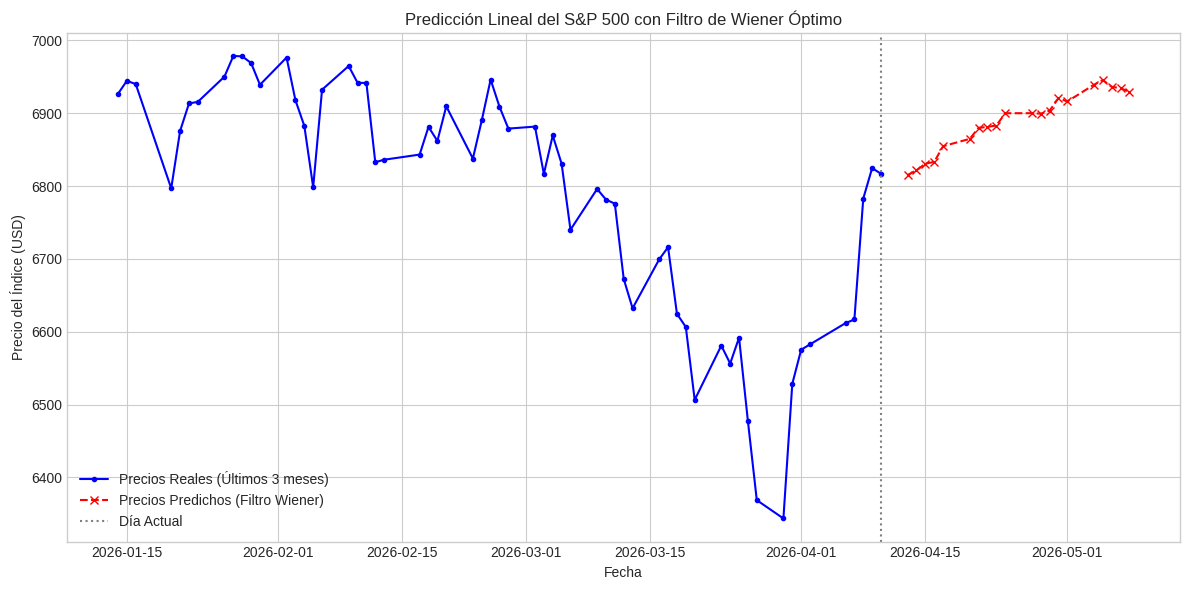

In [56]:
# 1. Devolver la media a los rendimientos predichos
rendimientos_pred_reales = x_pred_futuro + media_rendimientos

# 2. Convertir a precios proyectados partiendo del último precio real
precio_actual = precios.iloc[-1]
precios_proyectados = precio_actual * (1 + rendimientos_pred_reales / 100).cumprod()

# 3. Preparar datos para gráfica (últimos 3 meses = 60 días hábiles)
dias_historia = 60
precios_recientes = precios.iloc[-dias_historia:]
fechas_recientes = precios.index[-dias_historia:]

# Crear un índice de fechas futuras (solo para visualización continua)
fechas_futuras = pd.date_range(start=fechas_recientes[-1] + pd.Timedelta(days=1), periods=dias_prediccion, freq='B')

plt.figure(figsize=(12, 6))
plt.plot(fechas_recientes, precios_recientes, label='Precios Reales (Últimos 3 meses)', color='blue', marker='.')
plt.plot(fechas_futuras, precios_proyectados, label='Precios Predichos (Filtro Wiener)', color='red', marker='x', linestyle='--')

plt.title('Predicción Lineal del S&P 500 con Filtro de Wiener Óptimo')
plt.xlabel('Fecha')
plt.ylabel('Precio del Índice (USD)')
plt.axvline(fechas_recientes[-1], color='gray', linestyle=':', label='Día Actual')
plt.legend()
plt.tight_layout()
plt.show()

## Reto
Utilice el código anterior como referencia para predecir los valores futuros de alguna serie de tiempo WSS de su interés. En el caso de que la serie no sea WSS, aplique algunas de las trasnformaciones estudiadas anteriormente.